In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving store_customers.csv to store_customers.csv


In [ ]:
df = pd.DataFrame(pd.read_csv("store_customers.csv"))

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [ ]:
df.shape

(1000, 5)

In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0
999,1999,M,67.0,107.8,1.0


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0
999,1999,M,67.0,107.8,1.0


In [ ]:
df.shape

(982, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,982.000000,982.000000,982.000000,982.000000
mean,1500.304481,38.958248,57.326782,42.603870
std,288.698083,13.417748,28.658961,20.121469
min,1000.000000,18.000000,15.000000,1.000000
25%,1251.250000,30.000000,35.125000,31.000000
50%,1499.500000,36.000000,49.150000,47.000000
75%,1750.750000,44.000000,79.475000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns

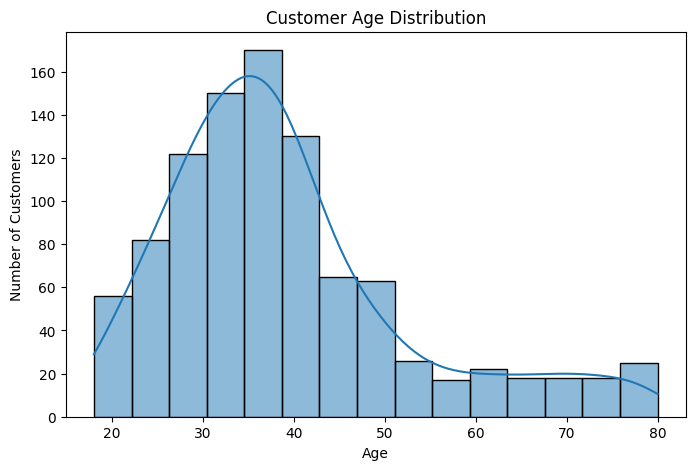

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

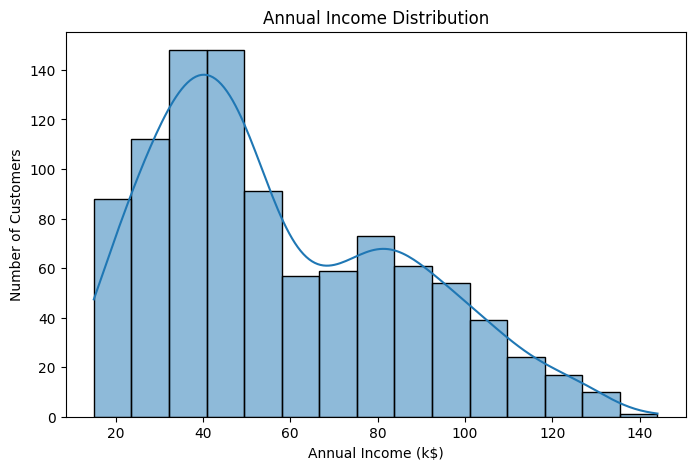

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

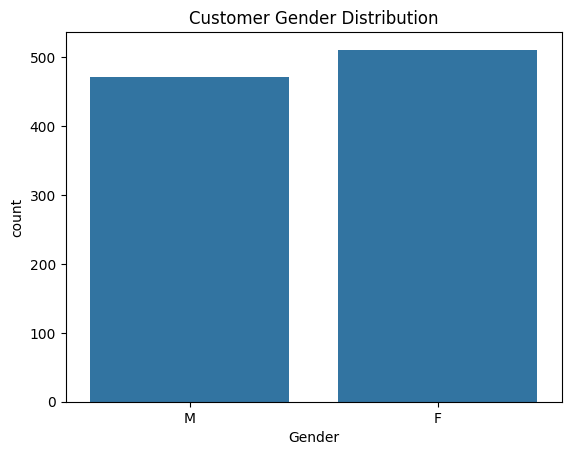

In [ ]:
sns.countplot(data=df, x="Gender")
plt.title("Customer Gender Distribution")
plt.show()

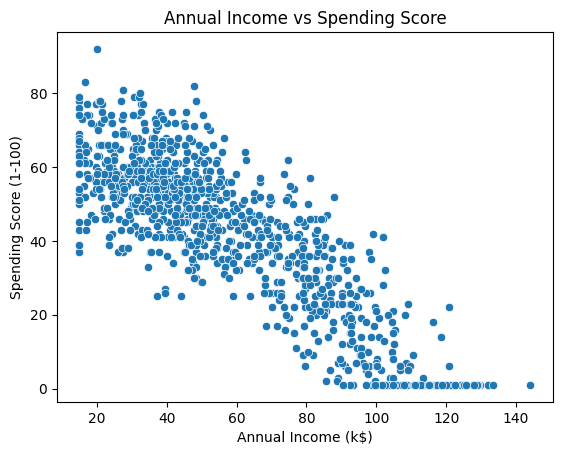

In [ ]:
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.show()

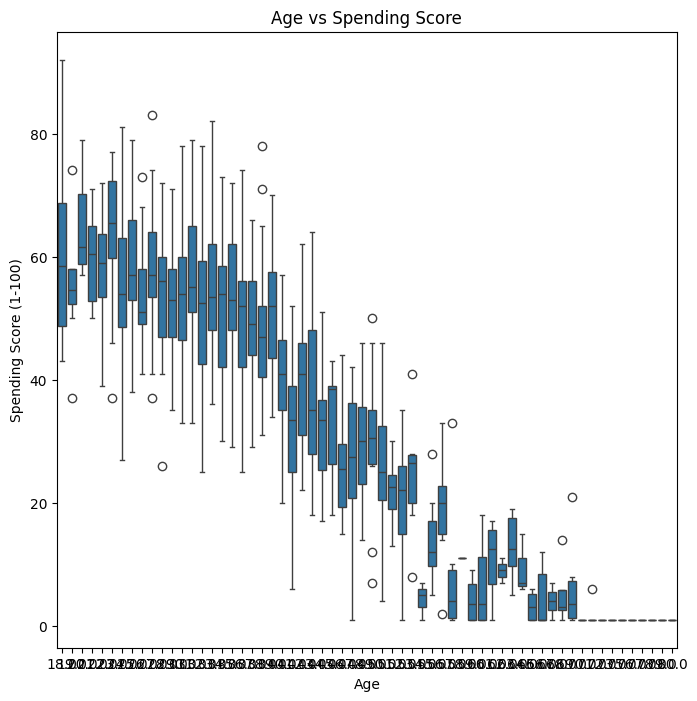

In [ ]:
plt.figure(figsize=(8,8))


sns.boxplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)"
)

plt.title("Age vs Spending Score")
plt.show()

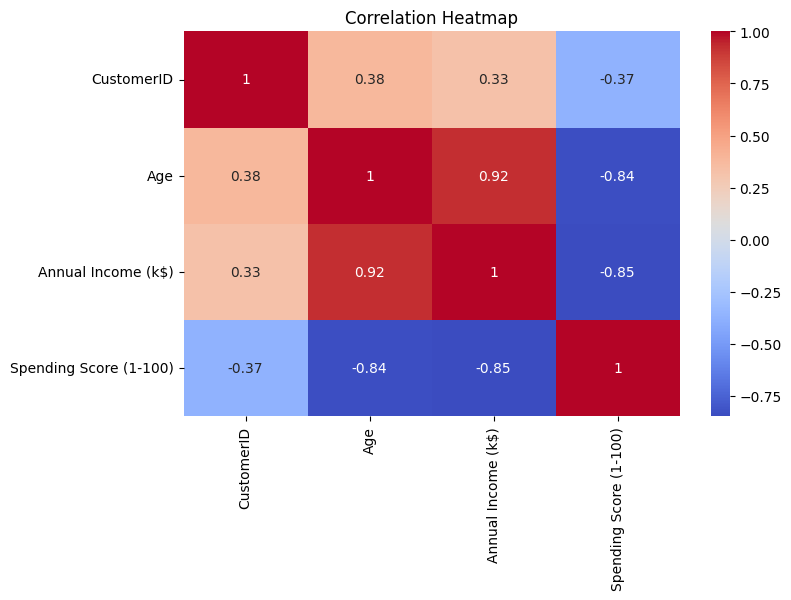

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

From EDA, we learned that our dataset has 982 customers. The average customer age is about 39 years, and most customers are between 30 and 40 years old. Customer income ranges from 15k to 144.1k, so there is a big difference in income levels. The average income is about 57.3k. The Spending Score ranges from 1 to 92, with an average score of 42.6, which shows that customers have different spending behaviors. We also used graphs to understand the relationship between Age, Income, and Spending Score. Overall, we learned that customers are different in their income and spending behavior, so we can use K-Means clustering to divide them into groups with similar behavior.

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [ ]:
df = df.drop("CustomerID", axis=1)

In [ ]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


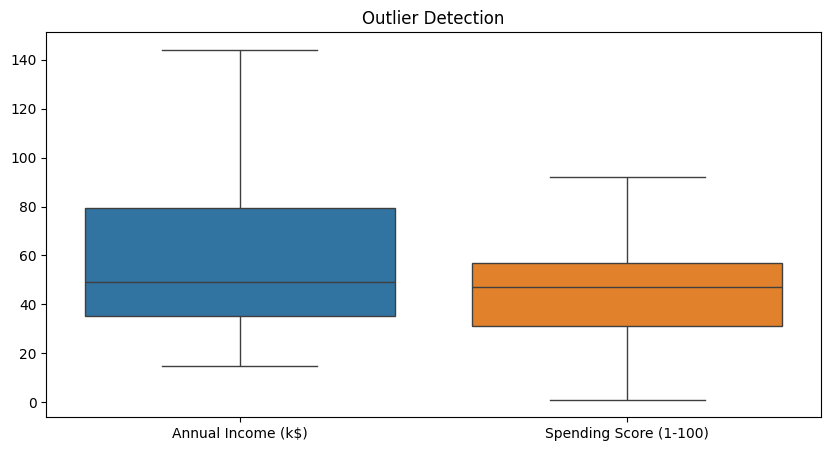

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["Annual Income (k$)", "Spending Score (1-100)"]])

plt.title("Outlier Detection")
plt.show()

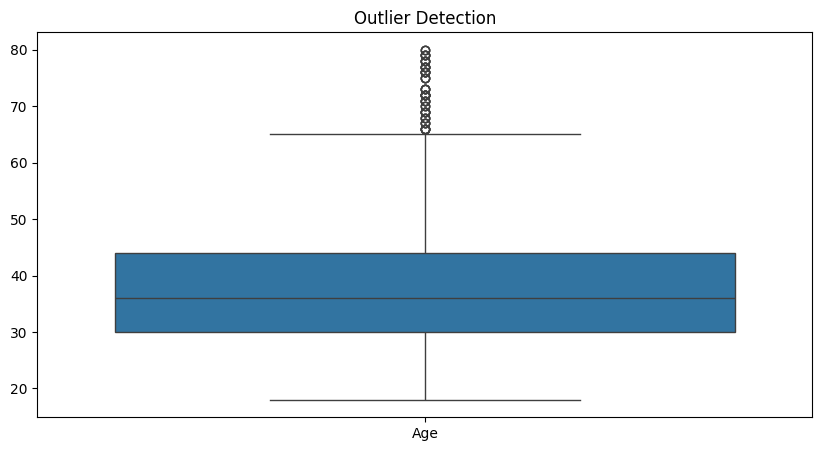

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["Age"]])

plt.title("Outlier Detection")
plt.show()

In [ ]:
df = df.drop("Gender", axis=1)

In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,39.0,59.9,58.0
1,34.0,48.4,37.0
2,40.0,70.5,26.0
3,47.0,81.1,30.0
4,33.0,42.1,58.0


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df < lower_bound) | (df > upper_bound))

outliers.sum()

,0
Age,72
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled[:5]

array([[ 0.00311325,  0.0898333 ,  0.76554926],
       [-0.36971739, -0.31164181, -0.27864393],
       [ 0.07767938,  0.45988863, -0.82560227],
       [ 0.59964228,  0.82994395, -0.62670833],
       [-0.44428352, -0.53158036,  0.76554926]])

In [ ]:
print("Mean:", X_scaled.mean(axis=0))
print("Standard Deviation:", X_scaled.std(axis=0))

Mean: [ 5.78853553e-17 -4.34140164e-17 -1.44713388e-16]
Standard Deviation: [1. 1. 1.]


In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

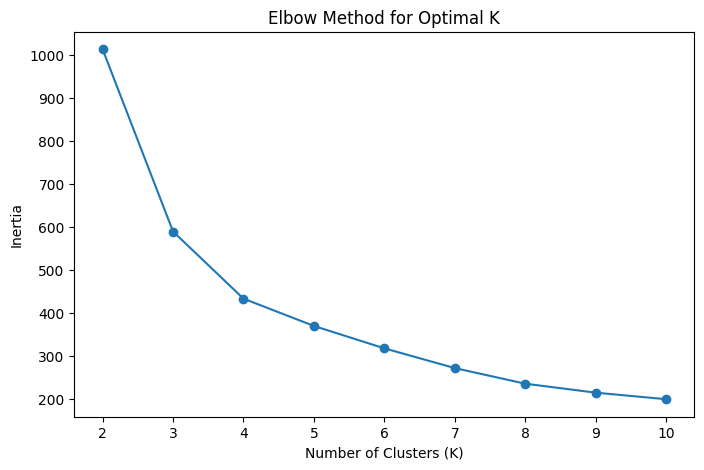

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [ ]:
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df["Cluster"] = clusters

In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,39.0,59.9,58.0,0
1,34.0,48.4,37.0,0
2,40.0,70.5,26.0,2
3,47.0,81.1,30.0,2
4,33.0,42.1,58.0,0


In [ ]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,329
1,128
2,208
3,317


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

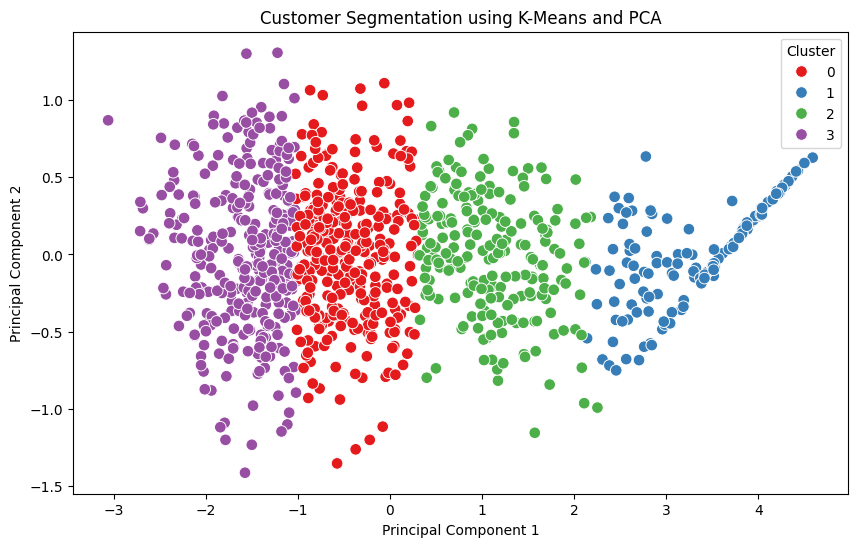

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Cluster"],
    palette="Set1",
    s=70
)

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,35.52,49.47,47.89
1,66.70,107.58,4.98
2,45.05,81.27,30.24
3,27.33,29.48,60.42


In [ ]:
cluster_count = df["Cluster"].value_counts().sort_index()

cluster_count

,count
Cluster,
0,329
1,128
2,208
3,317


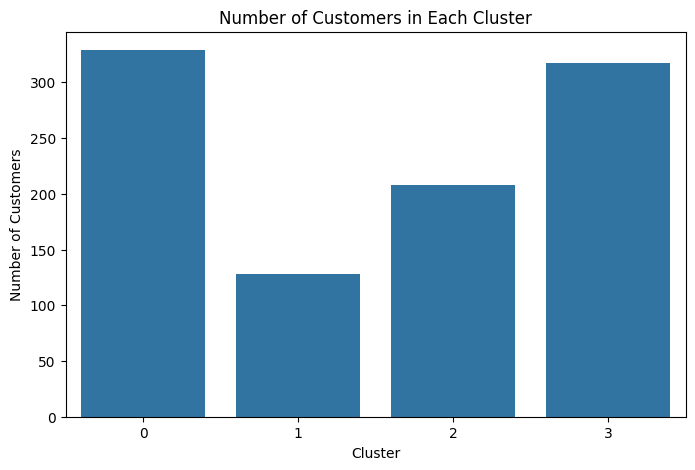

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Cluster")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

The cluster size analysis shows that the customers are not equally distributed among the four clusters. Cluster 0 has the largest number of customers, while Cluster 1 has the smallest number. Clusters 2 and 3 contain a moderate and large number of customers respectively

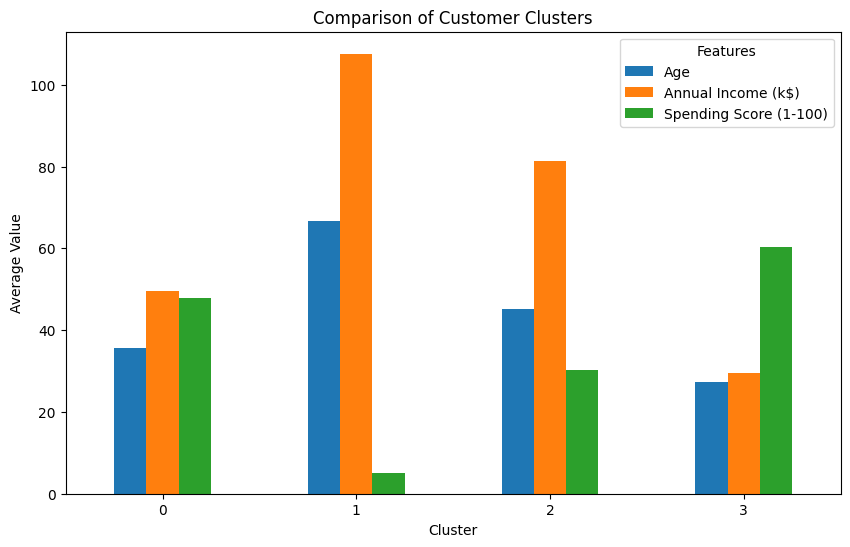

In [ ]:
cluster_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Value")

plt.xticks(rotation=0)
plt.legend(title="Features")

plt.show()

In [ ]:
explained_variance = pca.explained_variance_ratio_

print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

print("Total Explained Variance:",
      explained_variance.sum())


PC1: 0.913219627469008
PC2: 0.061692326103055466
Total Explained Variance: 0.9749119535720634


In [ ]:
print("PC1:", explained_variance[0] * 100, "%")
print("PC2:", explained_variance[1] * 100, "%")
print("Total:", explained_variance.sum() * 100, "%")

PC1: 91.3219627469008 %
PC2: 6.169232610305547 %
Total: 97.49119535720634 %


PCA was applied to reduce the three features into two principal components. PC1 explains 91.32% of the total variance, while PC2 explains 6.17%. Together, PC1 and PC2 explain 97.49% of the total variance. This means that most of the information in the original data is preserved after dimensionality reduction.

In [ ]:
cluster_names = {
    0: "Average Customers",
    1: "High-Income Low-Spending",
    2: "Higher-Income Low-Spending",
    3: "Young High-Spending"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

In [ ]:
df.head(10)

,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer_Segment
0,39.0,59.9,58.0,0,Average Customers
1,34.0,48.4,37.0,0,Average Customers
2,40.0,70.5,26.0,2,Higher-Income Low-Spending
3,47.0,81.1,30.0,2,Higher-Income Low-Spending
4,33.0,42.1,58.0,0,Average Customers
5,33.0,36.7,73.0,3,Young High-Spending
6,48.0,90.4,34.0,2,Higher-Income Low-Spending
7,41.0,74.8,35.0,2,Higher-Income Low-Spending
8,31.0,42.3,43.0,0,Average Customers
9,39.0,48.6,61.0,0,Average Customers


In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.38091063114456564


🔴 **Cluster 0 — Average Customers**

Insight:
Ye customers average income aur average spending rakhte hain.

Strategy:
Inko regular promotions, loyalty points aur bundle offers diye ja sakte hain taake inki spending increase ho.

🔵 **Cluster 1 — High-Income, Very Low-Spending**

Insight:
Ye sabse interesting segment hai. Average income 107.58k hai, lekin spending score sirf 4.98 hai.

Strategy:
In customers ko personalized offers, premium products aur special incentives diye ja sakte hain.

Goal: Inki high purchasing capacity ko actual spending mein convert karna.

🟢**Cluster 2 — Higher-Income, Low-Spending**

Insight:
Income relatively high (81.27k) hai, lekin spending score only 30.24 hai.

Strategy:
Targeted discounts, product recommendations aur promotional campaigns use karke spending increase ki ja sakti hai.

🟣 **Cluster 3 — Young, High-Spending ⭐**

Insight:
Ye customers average 27 years ke hain, income relatively low (29.48k) hai, lekin spending score 60.42 hai.

Strategy:
Inke liye trendy products, social-media campaigns, limited-time offers aur loyalty rewards effective ho sakte hain.